1. Load a Convolutional Neural Network

In [1]:
import torch

# get available device for running model
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# load best saved checkpoint
best_model = torch.load('./best_model.pth')

2. Test the network with an image


In [2]:
import matplotlib.pyplot as plt
import torchvision.transforms.v2 as transforms
from PIL import Image

# helper function for data visualization
def visualize(**images):
    """PLot images in one row."""
    n = len(images)
    plt.figure(figsize=(8, 5))
    for i, (name, image) in enumerate(images.items()):
        plt.subplot(1, n, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.title(' '.join(name.split('_')).title())
        plt.imshow(image)
    plt.show()

    - Preparing data and model for testing

In [3]:
transform = transforms.Compose([
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True),
    ])

img_path = './RetinaBloodVessel/train/image/0.png'
image = Image.open(img_path).convert('RGB')
image = transform(image)
image = image.unsqueeze(0)

    - Predicted result

In [4]:
# move model and image to available device
best_model.to(device)
image = image.to(device)

predict_mask = best_model.predict(image)

    - Visualize result from the model

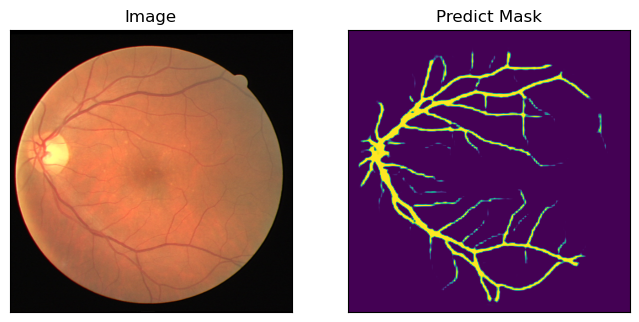

In [5]:
image = image.squeeze().cpu().numpy()
predict_mask = predict_mask.squeeze(0).cpu().numpy()
image, predict_mask = image.transpose(1, 2, 0), predict_mask.transpose(1, 2, 0)

visualize(
    image=image, 
    predict_mask=predict_mask,
)